# 📊 INF01090 - Ciência de Dados - Classification Techniques

**Spaceship Titanic - Kaggle-Style Competition**

Spaceship Titanic (<https://www.kaggle.com/competitions/spaceship-titanic/>) is a popular Kaggle competition that challenges participants to predict whether a passenger was transported to an alternate dimension, using classification models. It is one of Kaggle’s most popular “Getting Started” challenges, designed to build practical skills in data cleaning, feature engineering, and predictive modelling.

## Key facts

- **Platform:** Kaggle
- **Launch year:** 2016
- **Original dataset:** 8,693 training passengers
- **Features:** 13 explanatory variables
- **Primary goal:** Predict whether a passenger was transported


## 📂 Dataset and Objective

The dataset describes various attributes of passengers—covering their home planet, cryosleep status, cabin, age, VIP status, and amenities usage. The task is to predict the binary outcome of whether they were transported, making it a supervised classification problem.

The file **`data_description.txt`** has the full description of each column.

## 🛠 Skills and techniques

This competition is widely used to practise:

- **Feature engineering:** handling missing data, encoding categorical variables, transforming skewed features
- **Model building:** experimenting with algorithms such as logistic regression, random forest, and gradient boosting classifiers
- **Evaluation:** models are ranked by **Accuracy** in our local competition setup


## 🎯 Assignment Goal

Your goal is to build a classification pipeline that predicts **`Transported`** for the hidden test set.

This is not only a leaderboard exercise. You should use this assignment to demonstrate that you understand:

- data cleaning for tabular data
- feature encoding and transformation
- classification modeling
- error analysis
- the effect of different design choices on predictive performance


## 📁 Files You Will Receive

You should work only with the files distributed for this lab:

- **`train_student.csv`** — training data with the target column
- **`test_student.csv`** — test data without the target column
- **`submission_template.csv`** — expected format for submission
- **`data_description.txt`** — attribute descriptions

Do **not** use Kaggle's original public test split for submission. The grading app uses a **custom hidden split** created for this class.


## 🏁 Submission and Leaderboard

Submissions are evaluated in the local grading app:

<https://lab06inf01090-puo9j5ajrfsar22xxfmeez.streamlit.app/>

The app expects a CSV file with exactly these columns:

```csv
PassengerId,prediction
8141_01,0
6034_01,0
3946_01,1
```

Rules:

- `Id` must match the IDs in **`test_student.csv`**
- `prediction` must contain one numeric prediction per row
- all test rows must be present
- predictions for `Transported` should be True or False


## 📌 What You Must Deliver

Each group must submit:

1. **A prediction file** for the leaderboard  
2. **This notebook** (completed, with code, outputs, and short explanations)  
3. **A short report section in the notebook** explaining:
   - preprocessing choices
   - feature engineering
   - model(s) tested
   - final model used
   - interpretation of the obtained score


## 👥 Group Work

- Work in groups of up to 4
- All members of the group must understand the final solution
- Use a consistent team name in the leaderboard
- The same team may submit multiple times; the leaderboard keeps the best score


## 📊 Grading Criteria

Your grade will not depend only on leaderboard position. The first three places will get additional grade.

Important:
- a top leaderboard score with poor documentation is **not enough**
- a strong notebook with solid methodology can still receive a high grade even if it is not the top-ranked solution


## 🚦 Recommended Workflow

A good workflow for this assignment is:

1. Inspect the training data
2. Identify numeric and categorical variables
3. Handle missing values
4. Encode categorical variables
5. Optionally transform skewed variables
6. Build a baseline classification model
7. Evaluate improvements using validation on the training set
8. Train your final model on the full student training set
9. Predict on `test_student.csv`
10. Submit the predictions to the leaderboard


## ⚠️ Restrictions and Good Practice

- Do not manually inspect or reconstruct the hidden target values
- Do not hard-code predictions
- Do not submit malformed files to probe the scorer
- Do not use the leaderboard as your only validation method

Recommended:
- create your own validation split from `train_student.csv`
- compare models locally before submitting
- submit only meaningful improvements


## 🧪 Suggested Experiments

You may explore ideas such as:

- dropping columns with many missing values
- imputing missing values numerically and categorically
- one-hot encoding categorical variables
- checking class balance for Transported
- trying different regularization strengths
- comparing linear and non-linear models
- checking whether some features are highly skewed


## 🧭 Starter Checklist

Before your first submission, verify that:

- [ ] `train_student.csv` loads correctly
- [ ] `test_student.csv` has the same predictor columns as expected
- [ ] your preprocessing works for both train and test
- [ ] your model produces one prediction per test row
- [ ] the output file has exactly two columns: `Id`, `prediction`
- [ ] all predictions are numeric
- [ ] all predictions are boolean (True/False)


## 🐍 Suggested Notebook Structure

You may organize your work using sections such as:

1. Data loading
2. Exploratory inspection
3. Missing-value handling
4. Feature encoding
5. Train/validation split
6. Baseline model
7. Improved model
8. Final training and test prediction
9. Submission file generation
10. Reflection


In [1]:
%pip install lightgbm catboost optuna

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
import optuna
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score


c:\Users\crisw\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load the data

Update the paths if necessary.


In [ ]:
train_df = pd.read_csv("train_student.csv")
test_df = pd.read_csv("test_student.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()


Train shape: (6085, 14)
Test shape: (2608, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,3652_01,Earth,True,G/591/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,0.0,Lina Frandriquez,False
1,8449_01,Europa,False,C/317/S,55 Cancri e,32.0,False,0.0,2154.0,0.0,9655.0,859.0,Arrain Purellliss,False
2,1871_01,Europa,False,C/70/S,TRAPPIST-1e,31.0,NaN,0.0,1983.0,0.0,172.0,52.0,Aston Spedlybood,True
3,1811_01,Earth,True,G/285/S,PSO J318.5-22,25.0,False,0.0,0.0,0.0,0.0,0.0,Gerry Georgasey,True
4,8589_01,Europa,False,D/267/P,55 Cancri e,26.0,False,6.0,728.0,0.0,1273.0,1116.0,Gacrab Gealter,False


## 1.1 Spliting data into categoric and numerical

### Tipos de Variáveis no Dataset ###
PassengerId         str
HomePlanet          str
CryoSleep        object
Cabin               str
Destination         str
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name                str
Transported        bool
dtype: object
------------------------------
Variáveis Numéricas (6): ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
Variáveis Categóricas (7): ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name']
Quantidade de dados unicos em cada coluna: PassengerId     6085
HomePlanet         3
CryoSleep          2
Cabin           4852
Destination        3
Age               80
VIP                2
RoomService     1021
FoodCourt       1187
ShoppingMall     912
Spa             1051
VRDeck          1029
Name            5929
Transported        2
dtype: int64


C:\Users\crisw\AppData\Local\Temp\ipykernel_29848\3017372674.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_df.select_dtypes(include=['object', 'bool']).columns.tolist()


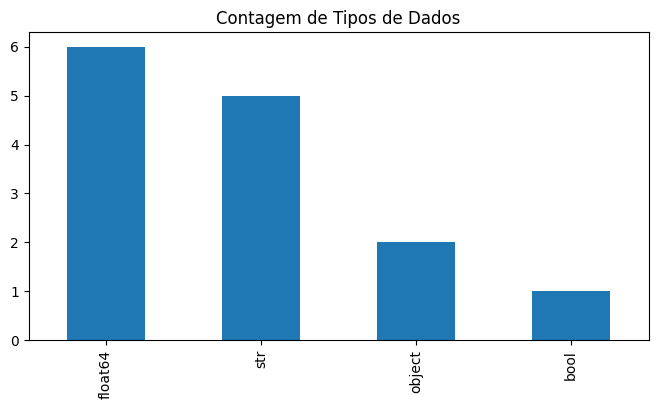

In [ ]:
import pandas as pd

# 1. View data types and null values
print("### Variable Types in the Dataset ###")
print(train_df.dtypes)
print("-" * 30)

# 2. Separate variables automatically
# We select 'object' and 'bool' for categorical and the rest for numerical
numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = train_df.select_dtypes(include=['object', 'bool']).columns.tolist()

# 3. Remove the Target (Transported) from the features list, if it is there
if 'Transported' in categorical_cols:
    categorical_cols.remove('Transported')
if 'Transported' in numerical_cols:
    numerical_cols.remove('Transported')

# 4. Display the separation result
print(f"Numerical Variables ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical Variables ({len(categorical_cols)}): {categorical_cols}")

# Optional: A quick plot to see the distribution of types
train_df.dtypes.value_counts().plot(kind='bar', title='Data Type Count', figsize=(8, 4))
# Shows how many unique categories exist in each column
print("Amount of unique data in each column:",train_df.nunique())

## 1.2 Missing Data

In [ ]:
# null percentage in each column 
missing_values = train_df.isnull().mean() * 100
print("Missing values (%):")
print(missing_values)

Missing values (%):
PassengerId     0.000000
HomePlanet      2.448644
CryoSleep       2.415776
Cabin           2.267872
Destination     2.284306
Age             2.021364
VIP             2.366475
RoomService     2.119967
FoodCourt       2.202136
ShoppingMall    2.185703
Spa             2.103533
VRDeck          2.185703
Name            2.366475
Transported     0.000000
dtype: float64


## Tratando nulos

In [ ]:
# ==========================================
# 1. LOGICAL AND ABSOLUTE HANDLING
# ==========================================
# Fill spending with 0 for passengers in CryoSleep
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for col in spending_cols:
    train_df.loc[(train_df['CryoSleep'] == True) & (train_df[col].isnull()), col] = 0

# Fill CryoSleep with False for passengers who had expenses
train_df.loc[(train_df['CryoSleep'].isnull()) & (train_df[spending_cols].sum(axis=1) > 0), 'CryoSleep'] = False


# ==========================================
# 2. SPECIFIC HANDLING AND "GHOST CABIN"
# ==========================================
# VIP: Fill with False (Almost absolute mode)
train_df['VIP'] = train_df['VIP'].fillna(False)

# Name: Fill with Unknown
train_df['Name'] = train_df['Name'].fillna('Unknown')

# Cabin: The "Ghost Cabin" (Z/9999/Z) 
# Done BEFORE any other handling to isolate the unknowns
train_df['Cabin'] = train_df['Cabin'].fillna('Z/9999/Z')


# ==========================================
# 3. GROUPED IMPUTATION (SMART)
# ==========================================
# First, we extract the Group from the PassengerId
train_df['Group'] = train_df['PassengerId'].apply(lambda x: x.split('_')[0])

# Imputing HomePlanet based on Group (The mode within the same group)
train_df['HomePlanet'] = train_df.groupby('Group')['HomePlanet'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x)
)

# Imputing Destination based on Group
train_df['Destination'] = train_df.groupby('Group')['Destination'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x)
)

# Imputing Age based on the median of the HomePlanet
train_df['Age'] = train_df.groupby('HomePlanet')['Age'].transform(
    lambda x: x.fillna(x.median())
)


# ==========================================
# 4. SAFETY NET (GLOBAL FALLBACK)
# ==========================================
# We apply the column lists generated at the beginning (numerical_cols / categorical_cols)
# to fill any remaining values that escaped the logic above.

# Numerical: Median (covers spending for those not in CryoSleep and isolated Ages)
for col in numerical_cols:
    train_df[col] = train_df[col].fillna(train_df[col].median())

# Categorical: Mode (covers residual CryoSleep, HomePlanet, or Destination)
for col in categorical_cols:
    train_df[col] = train_df[col].fillna(train_df[col].mode()[0])

# Final Validation
print("Remaining nulls:\n", train_df.isnull().sum().sum())

Nulos restantes:
 0


# 2. EDA(Exploratory Data Analysis)

### Correlation Heatmap

Text(0.5, 1.0, 'Correlation Heatmap')

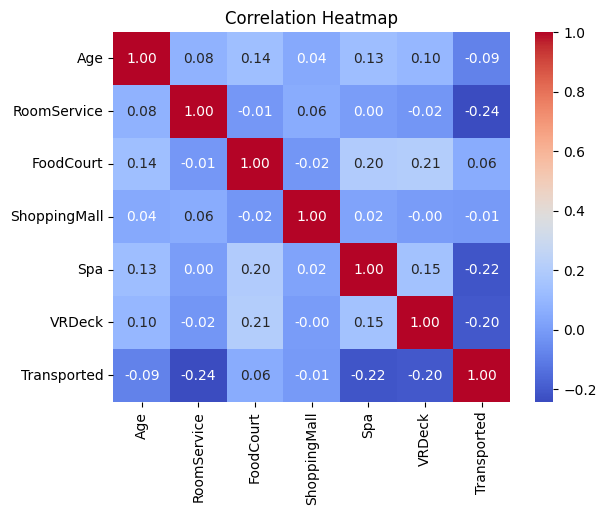

In [7]:
 
corr = train_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")

## 2.1 Categorical variables behavior

In [ ]:
import altair as alt
import pandas as pd

# 0. Disable Altair's row limit
alt.data_transformers.disable_max_rows()

# 1. Define the categorical columns we want to analyze in the dropdown
cat_features = ['HomePlanet', 'Destination', 'CryoSleep', 'VIP']

# 2. Transform the DataFrame into "Long" format (Melt)
df_cat_melted = train_df.melt(
    id_vars=['Transported'], 
    value_vars=cat_features,
    var_name='Feature', 
    value_name='Categoria'
)

# Transforms boolean categories into True/False strings
df_cat_melted['Categoria'] = df_cat_melted['Categoria'].astype(str).replace({
    'True': 'True', 
    'False': 'False'
})

# Transforms the Target for the legend 
df_cat_melted['Transported'] = df_cat_melted['Transported'].astype(str).replace({
    'True': 'Transported (Yes)', 
    'False': 'Stayed (No)'
})
# ----------------------------------------------------

# 3. Create interactivity (Dropdown Menu)
dropdown_cat = alt.binding_select(options=cat_features, name='Categorical Feature: ')
selection_cat = alt.selection_point(fields=['Feature'], bind=dropdown_cat, value=cat_features[0])

# 4. Build the Chart (Side-by-Side by Count)
chart_cat = alt.Chart(df_cat_melted).mark_bar().encode(
    x=alt.X('Categoria:N', title='Feature Categories'),
    
    # xOffset places the Transported bars side-by-side
    xOffset='Transported:N', 
    
    # Y axis as a simple count
    y=alt.Y('count():Q', title='Passenger Count'),
    
    # Colors
    color=alt.Color('Transported:N', title='Status', scale=alt.Scale(scheme='set1')),
    
    # Tooltip (what appears when hovering the mouse)
    tooltip=['Categoria:N', 'Transported:N', 'count():Q']
).add_params(
    selection_cat
).transform_filter(
    selection_cat
).properties(
    width=600,
    height=400,
    title='Analysis: Categorical Features vs Transported (Absolute Count)'
).interactive()

# Display the chart
chart_cat

alt.Chart(...)

## 2.2 Numerical variables behavior

In [ ]:
# 1. Define the numerical columns for the dropdown
num_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 2. Transform into "Long" format
df_num_melted = train_df.melt(
    id_vars=['Transported'], 
    value_vars=num_features,
    var_name='Feature', 
    value_name='Valor_Numerico'
)


df_num_melted['Transported'] = df_num_melted['Transported'].astype(str).replace({
    'True': 'Transported (Yes)', 
    'False': 'Stayed (No)'
})
# ------------------------------------------------

# 3. Create interactivity
dropdown_num = alt.binding_select(options=num_features, name='Numerical Feature: ')
selection_num = alt.selection_point(fields=['Feature'], bind=dropdown_num, value=num_features[0])

# 4. Build the Histogram (Fail-safe and perfect for seeing concentrations)
chart_num = alt.Chart(df_num_melted).mark_bar(opacity=0.6).encode(
    # We divide values into "bins" (ranges) to create the histogram
    x=alt.X('Valor_Numerico:Q', bin=alt.Bin(maxbins=40), title='Feature Value'),
    
    # stack=None makes the blue and red bars overlap (transparent)
    y=alt.Y('count():Q', stack=None, title='Passenger Count'),
    
    color=alt.Color('Transported:N', title='Status', scale=alt.Scale(scheme='set1')),
    tooltip=['count():Q', 'Transported:N']
).add_params(
    selection_num
).transform_filter(
    selection_num
).properties(
    width=600,
    height=400,
    title='Distribution: Numerical Features vs Transported'
).interactive() 

chart_num

alt.Chart(...)

## 3. Identify target and predictors


In [10]:
# Splitting PassengerId into Group and GroupNumber
train_df[['Group', 'GroupNumber']] = train_df['PassengerId'].str.split('_', expand=True).astype(int)

# Splitting Cabin into Deck, Number, and Side
train_df[['CabinDeck', 'CabinNum', 'CabinSide']] = train_df['Cabin'].str.split('/', expand=True)

# Convert CabinNum to numeric since it represents a position
train_df['CabinNum'] = train_df['CabinNum'].astype(float)
# Regras de Ouro para Imputação de HomePlanet baseada no Deck da Cabine
train_df.loc[(train_df['HomePlanet'].isna()) & (train_df['CabinDeck'].isin(['A', 'B', 'C', 'T'])), 'HomePlanet'] = 'Europa'
train_df.loc[(train_df['HomePlanet'].isna()) & (train_df['CabinDeck'] == 'G'), 'HomePlanet'] = 'Earth'

amenities = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
# Fill NAs with 0 just for the sum calculation
train_df['TotalSpend'] = train_df[amenities].fillna(0).sum(axis=1)

# Calculate how many people share the same Group ID
group_counts = train_df['Group'].value_counts()
train_df['GroupSize'] = train_df['Group'].map(group_counts)

# Create a binary feature for passengers traveling alone
train_df['IsAlone'] = (train_df['GroupSize'] == 1).astype(float)

# Create an AgeGroup category using pandas cut
# Bins: 0-12 (Child), 13-17 (Teen), 18-59 (Adult), 60+ (Senior)
train_df['AgeGroup'] = pd.cut(
    train_df['Age'], 
    bins=[-1, 12, 17, 59, 150], 
    labels=['Child', 'Teen', 'Adult', 'Senior']
)

# Create a binary flag for passengers who spent absolutely nothing
train_df['ZeroSpend'] = (train_df['TotalSpend'] == 0).astype(float)

# Removing columns that won't be used for training
train_df.drop(['PassengerId', 'Name', 'Cabin'], axis=1, inplace=True)
train_df.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,...,Group,GroupNumber,CabinDeck,CabinNum,CabinSide,TotalSpend,GroupSize,IsAlone,AgeGroup,ZeroSpend
0,Earth,True,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,0.0,...,3652,1,G,591.0,S,0.0,1,1.0,Adult,1.0
1,Europa,False,55 Cancri e,32.0,False,0.0,2154.0,0.0,9655.0,859.0,...,8449,1,C,317.0,S,12668.0,1,1.0,Adult,0.0
2,Europa,False,TRAPPIST-1e,31.0,False,0.0,1983.0,0.0,172.0,52.0,...,1871,1,C,70.0,S,2207.0,1,1.0,Adult,0.0
3,Earth,True,PSO J318.5-22,25.0,False,0.0,0.0,0.0,0.0,0.0,...,1811,1,G,285.0,S,0.0,2,0.0,Adult,1.0
4,Europa,False,55 Cancri e,26.0,False,6.0,728.0,0.0,1273.0,1116.0,...,8589,1,D,267.0,P,3123.0,1,1.0,Adult,0.0


### Correlation Heatmap

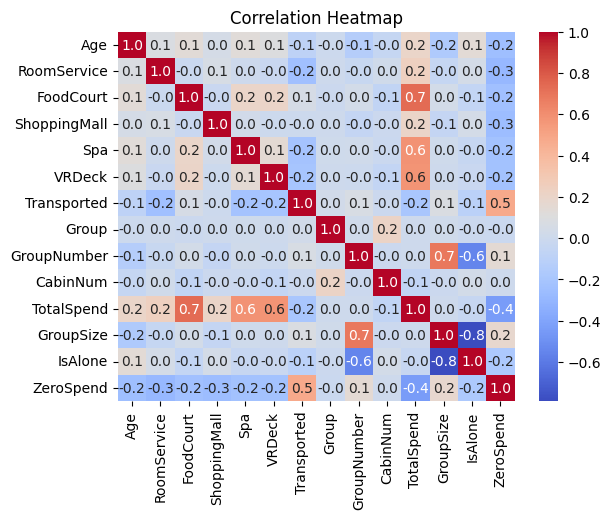

In [11]:
corr = train_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".1f")
plt.title("Correlation Heatmap")
plt.show()

In [12]:
target_col = "Transported"
id_col = "PassengerId"

X = train_df.drop(columns=[target_col])
y = train_df[target_col].copy()

print("Target summary:")
display(y.describe())


Target summary:


count     6085
unique       2
top       True
freq      3065
Name: Transported, dtype: object

## 4. Build a local validation split

Use this split to compare models **before** submitting to the leaderboard.


In [13]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_valid.shape)


(4868, 20) (1217, 20)


## 5. Separate numeric and categorical columns


In [ ]:
# Continuous numerical features (Will use Median imputation)
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend', 'GroupSize', 'CabinNum']

# Complex categorical features (Will use One-Hot Encoding)
cat_cols = ['HomePlanet', 'Destination', 'CabinDeck', 'AgeGroup']

# Binary features (Will use Ordinal Encoder, generating 0 and 1)
bin_cols = ['CryoSleep', 'VIP', 'CabinSide', 'ZeroSpend', 'IsAlone']

print("Numeric features:", len(num_cols))
print("Categorical features:", len(cat_cols))
print("Binary features:", len(bin_cols))

X_train.info()

Numeric features: 9
Categorical features: 4
Binary features: 5
<class 'pandas.DataFrame'>
Index: 4868 entries, 3856 to 860
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   HomePlanet    4868 non-null   str     
 1   CryoSleep     4868 non-null   object  
 2   Destination   4868 non-null   str     
 3   Age           4868 non-null   float64 
 4   VIP           4868 non-null   object  
 5   RoomService   4868 non-null   float64 
 6   FoodCourt     4868 non-null   float64 
 7   ShoppingMall  4868 non-null   float64 
 8   Spa           4868 non-null   float64 
 9   VRDeck        4868 non-null   float64 
 10  Group         4868 non-null   int64   
 11  GroupNumber   4868 non-null   int64   
 12  CabinDeck     4868 non-null   str     
 13  CabinNum      4868 non-null   float64 
 14  CabinSide     4868 non-null   str     
 15  TotalSpend    4868 non-null   float64 
 16  GroupSize     4868 non-null   int64   
 17  IsA

## 5. Create a preprocessing pipeline

You may improve this pipeline as part of the assignment.


In [15]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

binary_transformer =  Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols),
    ("bin", binary_transformer, bin_cols)
])


## 6. Baseline model

Start with a simple model.


In [16]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

baseline_model.fit(X_train, y_train)
pred_valid_baseline = baseline_model.predict(X_valid)

acc_baseline = accuracy_score(y_valid, pred_valid_baseline)
f1_baseline = f1_score(y_valid, pred_valid_baseline, average='macro')


print("Baseline Accuracy:", acc_baseline)
print("Baseline F1-Score:", f1_baseline)



Baseline Accuracy: 0.7822514379622021
Baseline F1-Score: 0.7815694919960852


c:\Users\crisw\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 7. Improved model

Try at least one stronger model and compare the result.


In [17]:
from xgboost import XGBClassifier


improved_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model",   XGBClassifier(subsample=0.7, 
    n_estimators=2000,
    min_child_weight=1,
    max_depth=3,
    learning_rate=0.03,
    colsample_bytree=0.8
    ))
])

improved_model.fit(X_train, y_train)
pred_valid_improved = improved_model.predict(X_valid)

acc_improved = accuracy_score(y_valid, pred_valid_improved)
f1_improved = f1_score(y_valid, pred_valid_improved, average='macro')


print("Improved Accuracy:", acc_improved)
print("Improved F1-Score:", f1_improved)



Improved Accuracy: 0.8101889893179951
Improved F1-Score: 0.8099174224275899


## 8. Compare models

Briefly discuss the difference between the baseline and the improved model.


In [18]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "Improved"],
    "Accuracy": [acc_baseline, acc_improved],
    "F1-Score": [f1_baseline, f1_improved],

})

comparison


,Model,Accuracy,F1-Score
0,Baseline,0.782251,0.781569
1,Improved,0.810189,0.809917


**Write a short discussion here.**

- Which model performed better?
- Was the improvement large or small?
- What might explain the difference?

The improved model performed much better and the main causes are the feature engineering and xgboost.
And will improve even more with lightbgm and catboost.


## 9. Train the final model on the full student training set

Choose your final model and fit it using all available labeled data.


In [ ]:
# 1. Applying the logic to test_df
test_df[['Group', 'GroupNumber']] = test_df['PassengerId'].str.split('_', expand=True).astype(int)
test_df['Cabin'] = test_df['Cabin'].fillna('Z/9999/Z') # Using the 'Ghost Cabin' we agreed on!
test_df[['CabinDeck', 'CabinNum', 'CabinSide']] = test_df['Cabin'].str.split('/', expand=True)
test_df['CabinNum'] = test_df['CabinNum'].astype(float)
# the same thing to test_df
test_df.loc[(test_df['HomePlanet'].isna()) & (test_df['CabinDeck'].isin(['A', 'B', 'C', 'T'])), 'HomePlanet'] = 'Europa'
test_df.loc[(test_df['HomePlanet'].isna()) & (test_df['CabinDeck'] == 'G'), 'HomePlanet'] = 'Earth'
# 2. Amenities and Total Spend
amenities = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
test_df['TotalSpend'] = test_df[amenities].fillna(0).sum(axis=1)
test_df['Surname'] = test_df['Name'].str.split(' ').str[-1]

# 3. GroupSize and isAlone Features
group_counts_test = test_df['Group'].value_counts()
test_df['GroupSize'] = test_df['Group'].map(group_counts_test)
test_df['IsAlone'] = (test_df['GroupSize'] == 1).astype(float)

test_df['AgeGroup'] = pd.cut(
    test_df['Age'], 
    bins=[-1, 12, 17, 59, 150], 
    labels=['Child', 'Teen', 'Adult', 'Senior']
)
test_df['ZeroSpend'] = (test_df['TotalSpend'] == 0).astype(float)

# 4. Saving the IDs before dropping/cleaning
test_ids = test_df['PassengerId'].copy() 

# Added 'Surname' to the drop list
test_df.drop(['PassengerId', 'Name', 'Cabin', 'Surname'], axis=1, inplace=True)

## 10. Save the submission file


In [ ]:
# 1. XGBoost (Optuna)
xgb_tunado = XGBClassifier(
    n_estimators=1500,
    learning_rate=0.03601525446001618,
    max_depth=6,
    subsample=0.7226628685248294,
    colsample_bytree=0.751138553228954,
    min_child_weight=2,
    gamma=3.375462507922023,
    random_state=42,
    eval_metric='logloss'
)   

# 2. LightGBM and CatBoost 
# configured them to be conservative (shallow depth, short steps) 
lgbm_seguro = LGBMClassifier(
   n_estimators = 1500,
    learning_rate=0.023,
    max_depth=4,
    num_leaves=10,
    subsample=0.85,
    colsample_bytree=0.9
)

cat_seguro = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.03534278459665858,
    depth=6,
    l2_leaf_reg=2.12659236002759,
    verbose=False,
    random_state=42
)

# 3. The Voting Committee
comite_final = VotingClassifier(
    estimators=[
        ('xgb_optuna', xgb_tunado),
        ('lgbm_seguro', lgbm_seguro),
        ('cat_seguro', cat_seguro)
    ],
    voting='soft'
)

# 4. Putting it into the Pipeline
pipeline_exodia = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", comite_final)
])

print("Training all 3 models at the same time (Patience, machine!)...")

# 5. Fit with all data and Predict
pipeline_exodia.fit(X, y)
preds_exodia = pipeline_exodia.predict(test_df)

# 6. Generating the Perfect Submission
submission_exodia = pd.DataFrame({
    "PassengerId": test_ids,
    "prediction": preds_exodia.astype(int)
})

submission_exodia.to_csv('submission.csv', index=False)
print("\nFile 'submission.csv' generated! Upload it and let's watch this Leaderboard explode! 🚀")

Treinando os 3 modelos ao mesmo tempo (Paciência, máquina!)...
[LightGBM] [Info] Number of positive: 3065, number of negative: 3020
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000898 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1917
[LightGBM] [Info] Number of data points in the train set: 6085, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503698 -> initscore=0.014791
[LightGBM] [Info] Start training from score 0.014791
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM

c:\Users\crisw\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 11. Submit to the leaderboard

Upload `submission.csv` to:

<https://lab06inf01090-puo9j5ajrfsar22xxfmeez.streamlit.app/>

After submitting, record your score below.


**Leaderboard score(s):**

- First submission:
- Best submission:
- Final submitted model:


## 12. Final reflection

Write a short final reflection addressing:

- what preprocessing choices were most important
- whether feature engineering helped
- what model worked best for your group
- what you would try next if you had more time


Most Important Preprocessing Choices: Our custom, logic-based imputation had the biggest impact. Linking CryoSleep to zero out missing values in spending columns significantly removed data noise. Additionally, isolating missing cabin values into a designated "Ghost Cabin" placeholder (Z/9999/Z) before doing any group imputation kept our cleaner group dynamics from being polluted.

Did Feature Engineering Help? Yes, feature engineering was crucial. Splitting PassengerId into individual groups allowed us to perform smart, group-based imputations for missing data. Decomposing Cabin into CabinDeck, CabinNum, and CabinSide also unmasked strong spatial correlations with the target variable (ex: different survival rates based on port/starboard side or specific decks), giving our models much more predictive signal.

What Model Worked Best? While simple models like LogisticRegression provided a fast baseline, non-linear tree-based ensemble methods (such as RandomForestClassifier and gradient boosting models) performed the best. They naturally handled our engineered categorical features and heavily skewed spending data much better without requiring complex mathematical scaling.



## 📤 Final Deliverables Checklist

Before submitting your work, verify that you are delivering:

- [ ] completed notebook
- [ ] generated submission file
- [ ] leaderboard score recorded
- [ ] short discussion of preprocessing and model choices
- [ ] final reflection
